In [1]:
import numpy as np
from scipy import io

In [2]:
color_map =  {
        0: "#c3121e", 1: "#0348a1", 2: "#ffb01c", 3: "#027608",
        4: "#1dace6", 5: "#9c5300", 6: "#9966cc", 7: "#ff4500" }

In [3]:
data_path = "Dataset_Wine_v8.mat"

data = io.loadmat(data_path, squeeze_me=True)
print("Here is the keys of the data dictionary: \n")
for key in data.keys():
    print(key)

Here is the keys of the data dictionary: 

__header__
__version__
__globals__
Aroma_compounds
Class
Data_GC
Data_GC_unaligned
Elution_profiles
FossWineScan
Foss_label
IR_spectra
IR_spectra_with_waterband
Label_Aroma_comp
Label_Elution_time
Label_Mass_channels
Label_Wine_samples
Mass_profiles
axis_spectra_wavenumber
axis_spectra_with_waterband_wavenumber


In [4]:
data_array = np.array(data['FossWineScan'])
print(data_array.shape)

(44, 14)


In [5]:
Lab_meas = np.array(data['Foss_label'])
print(Lab_meas.shape)

(14,)


In [6]:
Labels_wine = np.array(data['Label_Wine_samples']) 

print("Array shape of the wine sample labels: \n")
print(Labels_wine.shape) 

print("\n Wine sample labels: \n")
print(Labels_wine)

Array shape of the wine sample labels: 

(44,)

 Wine sample labels: 

['ARG-BNS1' 'ARG-DDA1' 'ARG-FFL1' 'ARG-FLM1' 'ARG-ICR1' 'ARG-SAL1'
 'AUS-CAV1' 'AUS-EAG1' 'AUS-HAR1' 'AUS-IB41' 'AUS-KIL1' 'AUS-KIR1'
 'AUS-NUG1' 'AUS-SOC1' 'AUS-TGH1' 'AUS-VAF1' 'AUS-WBL1' 'AUS-WES1'
 'CHI-CDD1' 'CHI-CDM1' 'CHI-CMO1' 'CHI-CSU1' 'CHI-GNE1' 'CHI-IND1'
 'CHI-LJO1' 'CHI-S151' 'CHI-SCH1' 'CHI-SHE1' 'CHI-SUN1' 'CHI-UND1'
 'CHI-UTA1' 'CHI-VDA1' 'CHI-VDS1' 'SOU-HHI1' 'SOU-INS1' 'SOU-KWV1'
 'SOU-NED1' 'SOU-PDM1' 'SOU-ROO1' 'SOU-RW21' 'SOU-SAV1' 'SOU-SIM1'
 'SOU-SPI1' 'SOU-SRE1']


In [7]:
country = []
for labels in Labels_wine:
    this_country = labels.split('-')[0]
    country.append(this_country)

print("\n Country of the wine samples: \n")
print(country)


 Country of the wine samples: 

['ARG', 'ARG', 'ARG', 'ARG', 'ARG', 'ARG', 'AUS', 'AUS', 'AUS', 'AUS', 'AUS', 'AUS', 'AUS', 'AUS', 'AUS', 'AUS', 'AUS', 'AUS', 'CHI', 'CHI', 'CHI', 'CHI', 'CHI', 'CHI', 'CHI', 'CHI', 'CHI', 'CHI', 'CHI', 'CHI', 'CHI', 'CHI', 'CHI', 'SOU', 'SOU', 'SOU', 'SOU', 'SOU', 'SOU', 'SOU', 'SOU', 'SOU', 'SOU', 'SOU']


In [32]:
country_unique = np.unique(country)
for i in range(len(country_unique)):
    print(f"Country: " + country_unique[i] + ' has ' 
    + str(np.sum(np.array(country) == country_unique[i])) + " samples.")

Country: ARG has 6 samples.
Country: AUS has 12 samples.
Country: CHI has 15 samples.
Country: SOU has 11 samples.


In [8]:
import pandas as pd

df = pd.DataFrame(data_array, columns=Lab_meas)

df.head()

,Ethanol,TotalAcid,VolatileA,MalicAcid,pH,LacticAc,ReSugar,CitricAcid,CO2,Density,FolinC,Glycerol,Methanol,TartaricA
0,13.62,3.54,0.29,0.89,3.71,0.78,1.46,0.31,85.610001,0.99,60.919998,9.72,0.16,1.74
1,14.06,3.74,0.59,0.24,3.73,1.25,2.42,0.18,175.199997,1.00,70.639999,10.05,0.20,1.58
2,13.74,3.27,0.47,-0.07,3.87,1.13,1.52,0.39,513.739990,0.99,63.590000,10.92,0.18,1.24
3,13.95,3.66,0.47,0.09,3.79,1.00,4.17,0.41,379.399994,1.00,73.300003,9.69,0.23,2.26
4,14.47,3.66,0.38,0.61,3.70,0.81,1.25,0.14,154.880005,0.99,71.690002,10.81,0.20,1.22


In [9]:
df.insert(0, 'Country', country, allow_duplicates=True)

In [38]:
df

,Country,Ethanol,TotalAcid,VolatileA,MalicAcid,pH,LacticAc,ReSugar,CitricAcid,CO2,Density,FolinC,Glycerol,Methanol,TartaricA
0,ARG,13.62,3.54,0.29,0.89,3.71,0.78,1.46,0.31,85.610001,0.99,60.919998,9.72,0.16,1.74
1,ARG,14.06,3.74,0.59,0.24,3.73,1.25,2.42,0.18,175.199997,1.00,70.639999,10.05,0.20,1.58
2,ARG,13.74,3.27,0.47,-0.07,3.87,1.13,1.52,0.39,513.739990,0.99,63.590000,10.92,0.18,1.24
3,ARG,13.95,3.66,0.47,0.09,3.79,1.00,4.17,0.41,379.399994,1.00,73.300003,9.69,0.23,2.26
4,ARG,14.47,3.66,0.38,0.61,3.70,0.81,1.25,0.14,154.880005,0.99,71.690002,10.81,0.20,1.22
5,ARG,14.61,3.45,0.52,0.16,3.92,1.76,1.40,0.10,156.300003,0.99,71.790001,10.19,0.19,0.90
6,AUS,13.65,4.31,0.32,0.18,3.60,1.37,3.80,0.24,462.619995,1.00,59.599998,10.66,0.25,1.81
7,AUS,14.12,3.88,0.37,0.36,3.70,1.02,4.32,0.32,244.149994,1.00,59.500000,11.07,0.25,1.65
8,AUS,13.13,3.83,0.27,0.40,3.66,1.13,3.99,0.34,212.000000,1.00,59.419998,8.89,0.23,2.12
9,AUS,13.49,3.69,0.32,0.50,3.70,1.02,6.40,0.13,419.380000,1.00,63.860000,10.35,0.26,1.81


Text(0.5, 1.0, 'Malic Acid')

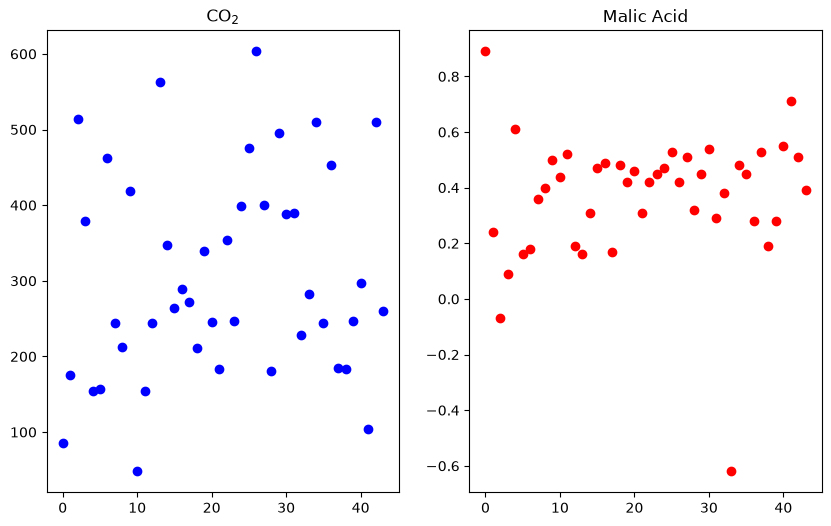

In [46]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 6))
x = df["CO2"]

ax[0].plot(x, marker='o', linestyle='None', color='blue')
ax[0].set_title("CO$_2$")

x = df["MalicAcid"]
ax[1].plot(x, marker='o', linestyle='None', color='red')
ax[1].set_title("Malic Acid")

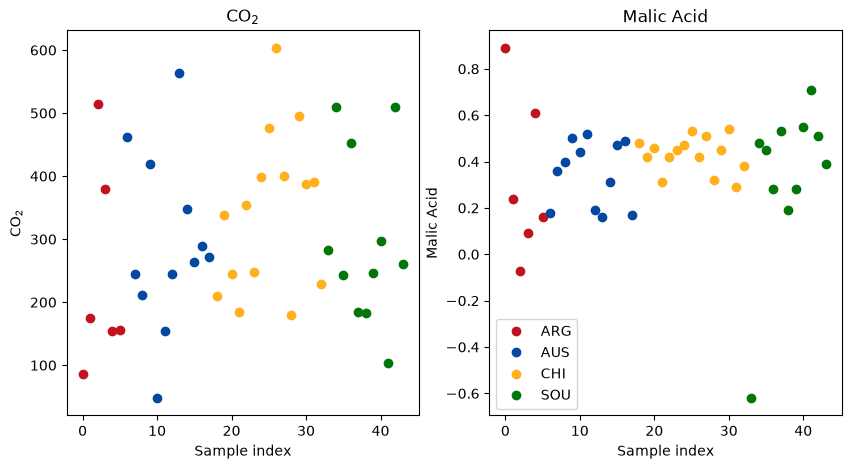

In [59]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
x = df['CO2']
y = df['MalicAcid']

country_unique = np.unique(df['Country'])

for country in country_unique:
    ax[0].plot(x[df['Country'] == country], marker='o', linestyle='None', label=country, color=color_map[np.where(country_unique == country)[0][0]])
    ax[0].set_title("CO$_2$") 
    ax[0].set_xlabel("Sample index")
    ax[0].set_ylabel("CO$_2$")

    ax[1].plot(y[df['Country'] == country], marker='o', linestyle='None', label=country, color=color_map[np.where(country_unique == country)[0][0]])
    ax[1].set_title("Malic Acid")
    ax[1].set_xlabel("Sample index") 
    ax[1].set_ylabel("Malic Acid")

plt.legend()

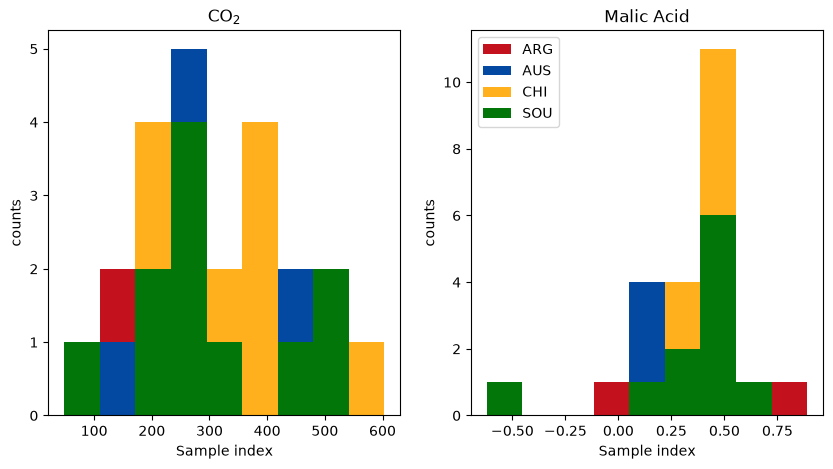

In [62]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
x = df['CO2']
y = df['MalicAcid']

country_unique = np.unique(df['Country'])

for country in country_unique:
    bins = np.linspace(np.min(x), np.max(x), 10)
    ax[0].hist(x[df['Country'] == country], bins=bins, label=country, color=color_map[np.where(country_unique == country)[0][0]])
    ax[0].set_title("CO$_2$") 
    ax[0].set_xlabel("Sample index")
    ax[0].set_ylabel("counts")

    bins = np.linspace(np.min(y), np.max(y), 10)
    ax[1].hist(y[df['Country'] == country], bins=bins, label=country, color=color_map[np.where(country_unique == country)[0][0]])
    ax[1].set_title("Malic Acid")
    ax[1].set_xlabel("Sample index") 
    ax[1].set_ylabel("counts")

plt.legend()

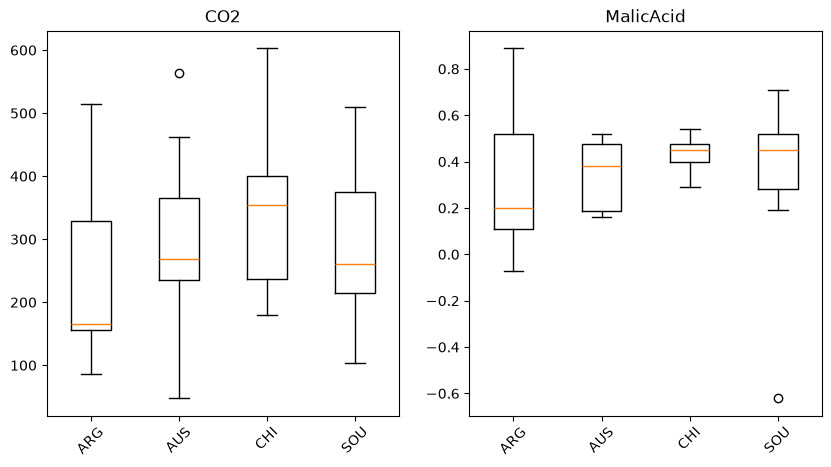

In [ ]:
import matplotlib.pyplot as plt
country_unique = np.unique(df['Country'])
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
PROPS =["CO2", "MalicAcid"]

cont = -1
for prop in PROPS:
    PROPER = df[prop]
    data = []
    cont = cont + 1
    for i in range(len(country_unique)):
        data.append(PROPER[df['Country'] == country_unique[i]])
    ax[cont].boxplot(data)
    ax[cont].set_title(prop)
    ax[cont].set_xticks(ticks = np.arange(1, len(country_unique)+1), labels = country_unique, rotation = 45)
    plt.xticks(ticks = np.arange(1, len(country_unique)+1), labels = country_unique, rotation = 45)


In [ ]:
def PlotBoxPlots(DataM, country, country_unique, Lab_meas, PROPS):
    fig,axs = plt.subplots(1,
                        len(PROPS),
                        figsize=(len(PROPS)*3,3))
    axes = axs.flatten()
    cont = -1
    for PROPNUM in PROPS:
        PROPER = DataM.iloc[:, PROPNUM].values
        data = []
        for kk in range(len(country_unique)):
            data.append(PROPER[country == country_unique[kk]])
        cont = cont + 1
        axes[cont].boxplot(data)
        axes[cont].set_title(Lab_meas[PROPNUM])
        axes[cont].set_xticks(ticks = np.arange(1, 
                                            len(country_unique)+1), 
                                            labels = country_unique, 
                                            rotation = 45)
        plt.xticks(ticks = np.arange(1, len(country_unique)+1), 
                                    labels = country_unique, 
                                    rotation = 45)

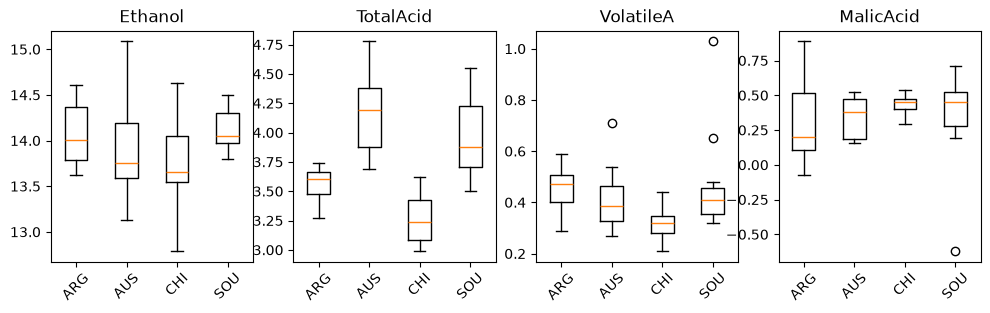

In [45]:
PlotBoxPlots(data_array, df["Country"], country_unique, Lab_meas, [0, 1, 2, 3])

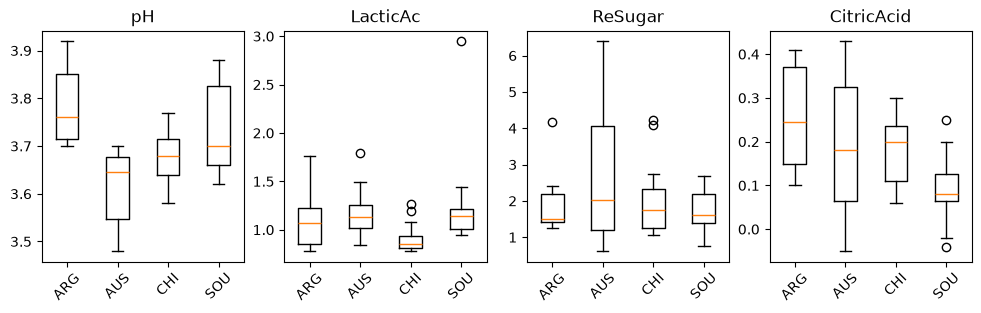

In [46]:
PlotBoxPlots(data_array, df["Country"], country_unique, Lab_meas, [4, 5, 6, 7])

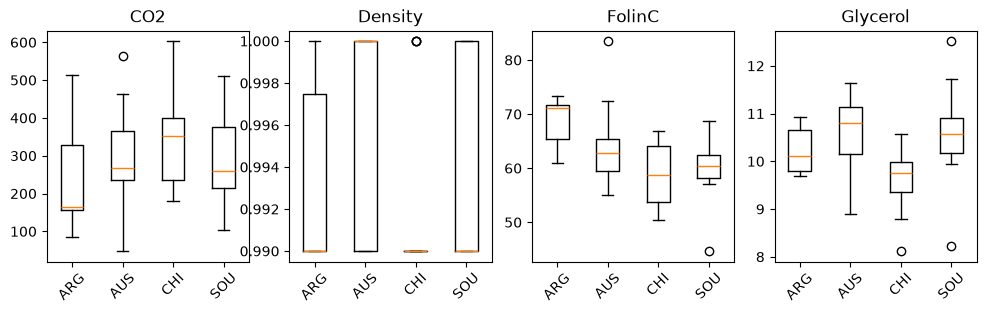

In [47]:
PlotBoxPlots(data_array, df["Country"], country_unique, Lab_meas, [8, 9, 10, 11])

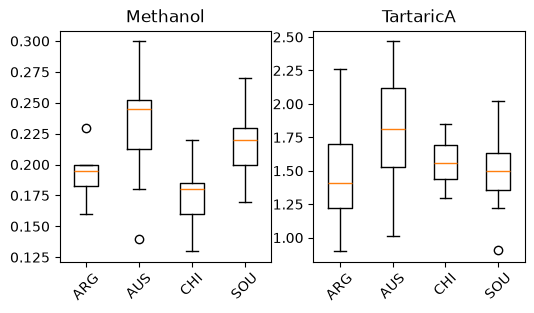

In [48]:
PlotBoxPlots(data_array, df["Country"], country_unique, Lab_meas, [12, 13])

In [ ]:
def Classifier1(sample):
    pH = sample['pH'] 
    if pH > 3.7:
        estimatedOr = 'ARG'
    else:
        estimatedOr = 'AUS'
    return estimatedOr

sample = df.loc[1] # define the sample to be classified
estimatedOr = Classifier1(sample) 

print(f"Estimated country of the sample is:  {estimatedOr}")

Estimated country of the sample is:  ARG


In [ ]:
def Classifier2(sample):
    pH = sample['pH']
    tA = sample['TotalAcid'] 
    if pH > 3.7:
        estimatedOr = 'ARG'
    else:
        if tA > 3.6:
            estimatedOr = 'AUS'
        else:
            estimatedOr = 'CHI'
    return estimatedOr

sample = df.loc[13] # define the sample to be classified
estimatedOr = Classifier2(sample) 

print(f"Estimated country of the sample is:  {estimatedOr}")

Estimated country of the sample is:  AUS
